In [68]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import json
import os 
from skimage.segmentation import slic
from sklearn.linear_model import Lasso
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kendalltau, spearmanr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64

# Load the pre-trained ResNet18 model
model = models.resnet18(pretrained=True)
model.eval()  # Set model to evaluation mode
model.to(device)
# Define the image preprocessing transformations
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]   
    )
])

# Load the ImageNet class index mapping
with open("imagenet_class_index.json") as f:
    class_idx = json.load(f)
idx2label = [class_idx[str(k)][1] for k in range(len(class_idx))]
idx2synset = [class_idx[str(k)][0] for k in range(len(class_idx))]
id2label = {v[0]: v[1] for v in class_idx.values()}

imagenet_path = './imagenet_samples'

# List of image file paths
image_paths = os.listdir(imagenet_path)

/home/jiayou/hw-521/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jiayou/hw-521/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [69]:
gt = []

for img_path in image_paths:
    # Open and preprocess the image
    my_img = os.path.join(imagenet_path, img_path)
    input_image = Image.open(my_img).convert('RGB')
    image = preprocess(input_image)
    input_batch = image.unsqueeze(0)  # Create a mini-batch as expected by the model

    # Move the input and model to GPU if available
    if torch.cuda.is_available():
        device = torch.device('cuda')
        input_batch = input_batch.to(device)
        model.to(device)

    # Perform inference
    with torch.no_grad():
        output = model(input_batch)

    # Get the predicted class index
    _, predicted_idx = torch.max(output, 1)
    predicted_idx = predicted_idx.item()
    predicted_synset = idx2synset[predicted_idx]
    predicted_label = idx2label[predicted_idx]
    gt.append((input_image, predicted_idx, img_path))


# LIME & SmoothGrad


Predicted label: n04118776 (rule) for image paintbrush.JPEG


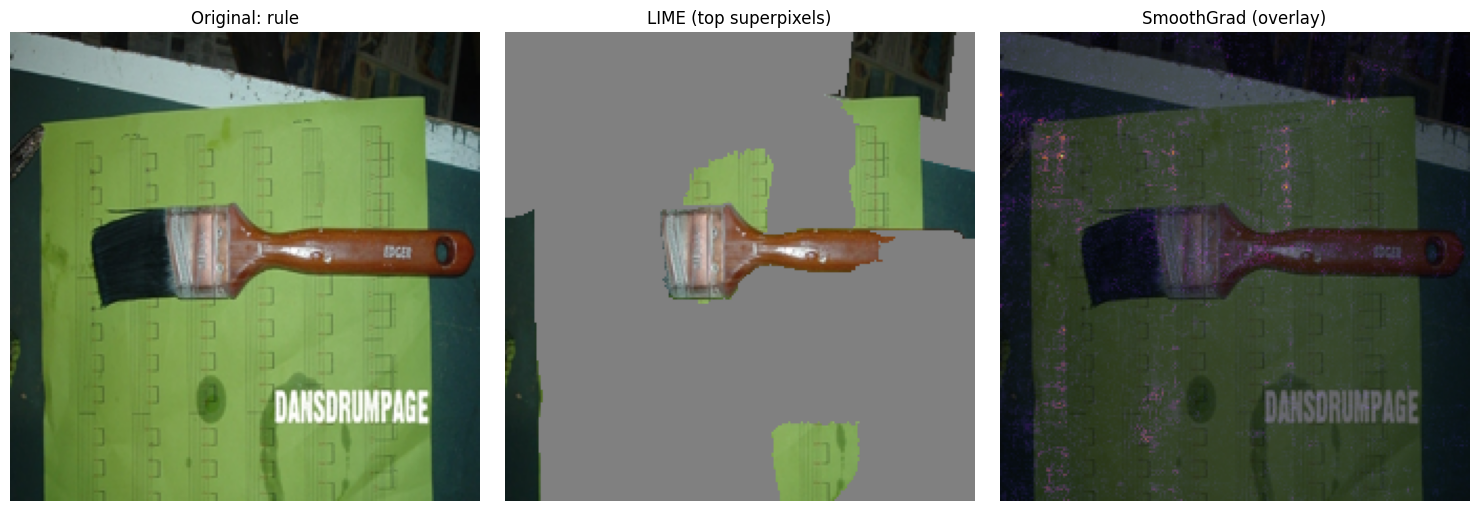


Predicted label: n01806143 (peacock) for image peacock.JPEG


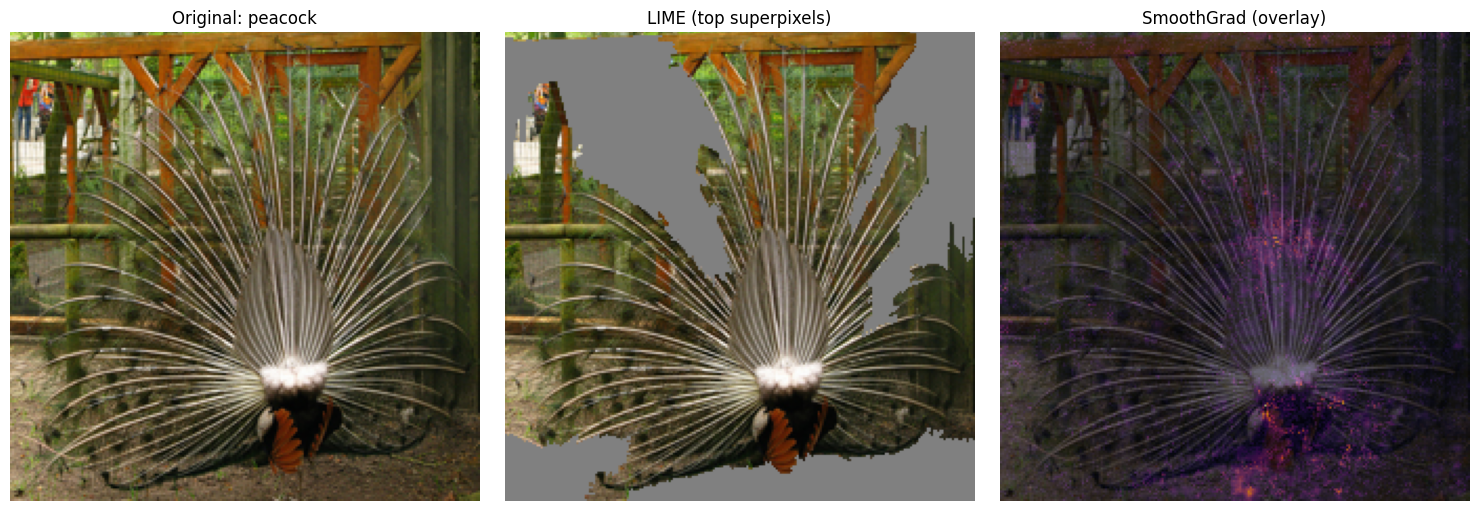


Predicted label: n03250847 (drumstick) for image mousetrap.JPEG


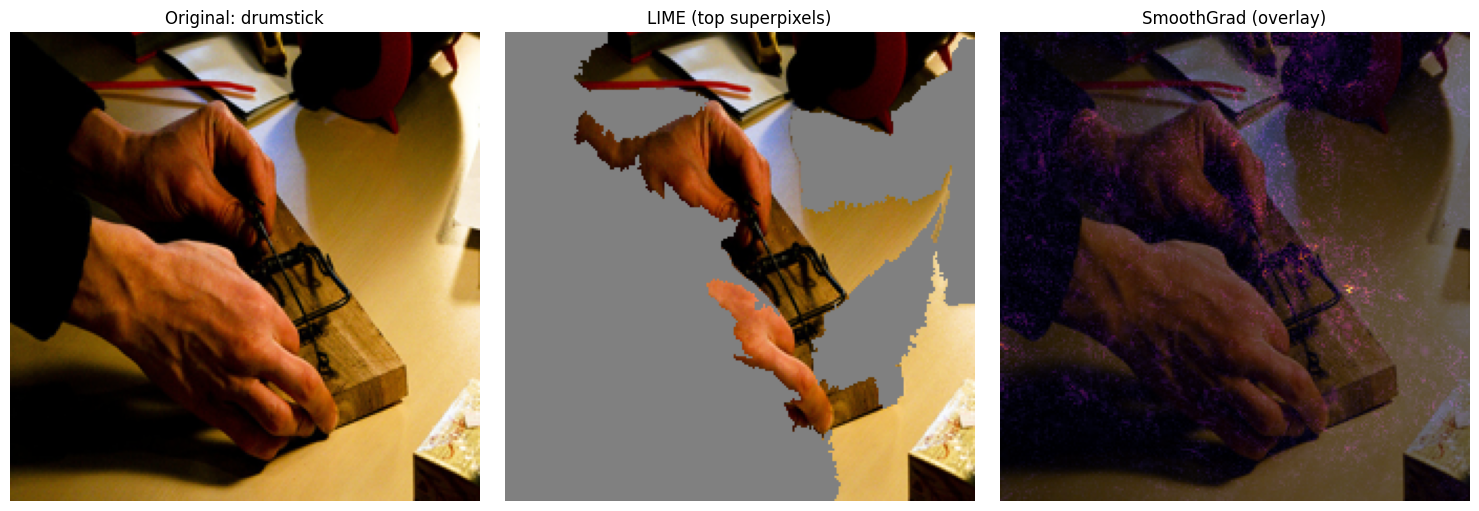


Predicted label: n03792782 (mountain_bike) for image mountain_bike.JPEG


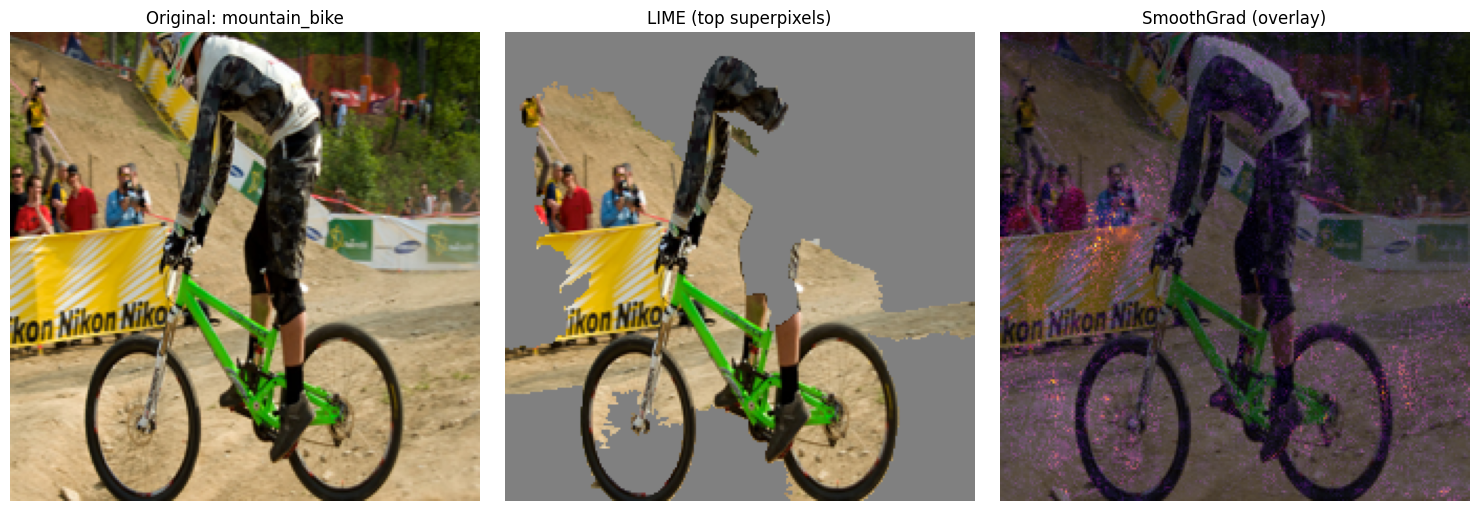


Predicted label: n03938244 (pillow) for image piggy_bank.JPEG


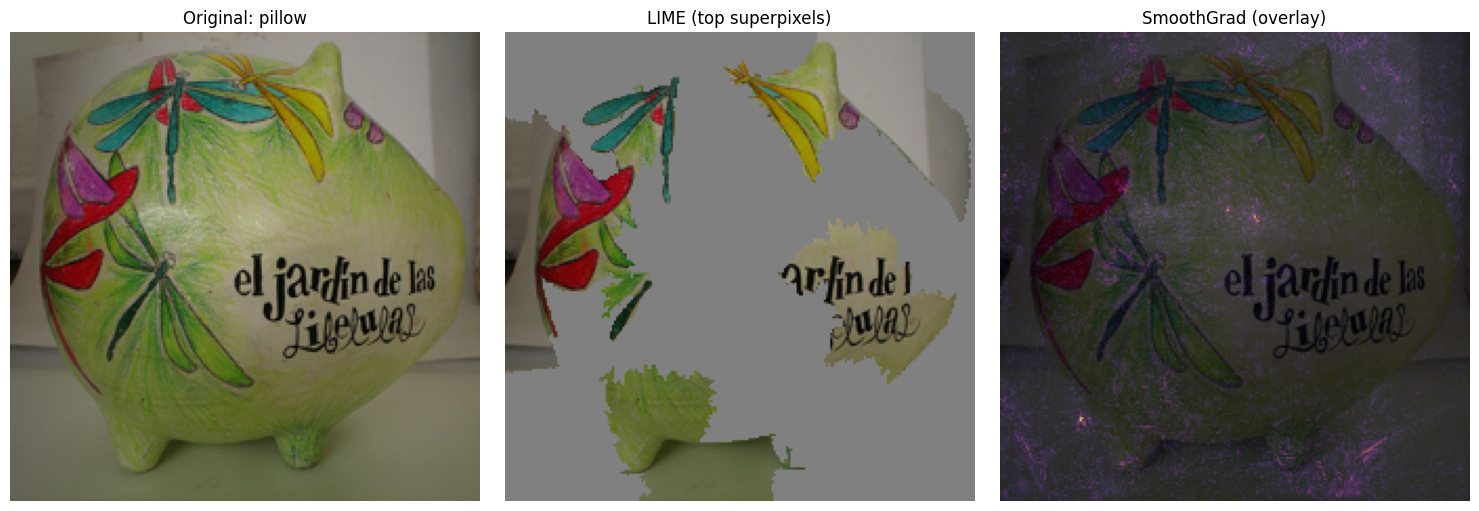

In [70]:
def lime(model, image, preprocess, predicted_class, num_samples=100, num_features=1):
    image_array = np.array(image)
    segments = slic(image_array, n_segments=50)
    num_superpixels = int(segments.max()) + 1
    perturbations = np.random.randint(2, size=(num_samples, num_superpixels), dtype=bool)
    preds = []
    distances = []
    for mask in perturbations:
        perturbed_image = image_array.copy()
        for sp in range(num_superpixels):
            perturbed_image[segments == sp] = [128, 128, 128] if mask[sp] else perturbed_image[segments == sp]
        perturbed_image_array = preprocess(Image.fromarray(perturbed_image)).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(perturbed_image_array)
        preds.append(output[0, predicted_class].cpu().item())
        distance = np.sum(mask) / num_superpixels
        distances.append(distance)

    preds = np.array(preds)
    distances = np.array(distances)
    kernel_width = 0.2
    weights = np.sqrt(np.exp(-(distances ** 2) / (kernel_width ** 2)))
    lasso = Lasso(alpha=0.01)
    lasso.fit(perturbations, preds, sample_weight=weights)
    weights = lasso.coef_
    top_features = np.argsort(np.abs(weights))[-num_features:]
    top_weights = np.zeros_like(weights)
    top_weights[top_features] = weights[top_features]

    return segments, top_weights

def smoothgrad(model, image, preprocess, target_class, num_samples=100, noise_level=0.15):
    img_t = preprocess(image).unsqueeze(0).to(device)

    grads = []
    for _ in range(num_samples):
        noise = torch.randn_like(img_t) * noise_level
        noisy = (img_t + noise).requires_grad_()
        output = model(noisy)
        score = output[0, target_class]
        grad = torch.autograd.grad(score, noisy)[0].detach().cpu().numpy()[0]
        grads.append(grad)

    avg_grad = np.mean(grads, axis=0)
    return avg_grad

def visualize_combined(image, segments, lime_weights, avg_grad, predicted_label):
    image_np = np.array(image).copy()
    masked_image = image_np.copy()
    unimportant = np.where(lime_weights == 0)[0]
    for idx in unimportant:
        masked_image[segments == idx] = (128, 128, 128)

    abs_grad = np.abs(avg_grad)
    if abs_grad.ndim == 3:  # C x H x W
        saliency = np.sum(abs_grad, axis=0)
    else:
        saliency = abs_grad
    saliency = saliency - saliency.min()
    if saliency.max() > 0:
        saliency = saliency / saliency.max()
    else:
        saliency = np.zeros_like(saliency)

    saliency_resized = np.array(Image.fromarray(saliency).resize(image.size, Image.BILINEAR))

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(image_np)
    ax[0].set_title(f"Original: {predicted_label}")
    ax[0].axis('off')

    ax[1].imshow(masked_image)
    ax[1].set_title("LIME (top superpixels)")
    ax[1].axis('off')

    ax[2].imshow(image_np, alpha=1.0)
    ax[2].imshow(saliency_resized, cmap='inferno', alpha=0.6)
    ax[2].set_title("SmoothGrad (overlay)")
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()


for image, predicted_idx, img_path in gt:
    predicted_synset = idx2synset[predicted_idx]
    predicted_label = idx2label[predicted_idx]
    print(f"\nPredicted label: {predicted_synset} ({predicted_label}) for image {img_path}")

    temp_image_for_lime = image.resize((224, 224))
    
    segments, lime_weights = lime(model=model, image=temp_image_for_lime, preprocess=preprocess,
                                 predicted_class=predicted_idx, num_samples=100, num_features=10)
    avg_grad = smoothgrad(model, image, preprocess, predicted_idx, num_samples=50, noise_level=0.15)

    visualize_combined(temp_image_for_lime, segments, lime_weights, avg_grad, predicted_label)


# feature rankings

In [71]:
for image, predicted_idx, img_path in gt:
    predicted_synset = idx2synset[predicted_idx]
    predicted_label = idx2label[predicted_idx]
    print(f"\nPredicted label: {predicted_synset} ({predicted_label}) for image {img_path}")

    segments, lime_weights = lime(model, image, preprocess, predicted_idx, num_samples=100, num_features=10)
    avg_grad = smoothgrad(model, image, preprocess, predicted_idx, num_samples=50, noise_level=0.15)
    saliency = np.sum(np.abs(avg_grad), axis=0)
    segments_resized = np.array(Image.fromarray(segments.astype(np.int32)).resize(saliency.shape[::-1], resample=Image.NEAREST))
    super_pixel_labels = np.unique(segments_resized)
    num_superpixels = np.max(super_pixel_labels) + 1
    smoothgrad_importance = np.zeros(num_superpixels)
    for label in super_pixel_labels:
        smoothgrad_importance[label] = saliency[segments_resized == label].mean()

    lime_ranks = np.argsort(-np.abs(lime_weights))
    smoothgrad_ranks = np.argsort(-np.abs(smoothgrad_importance))

    kendall_corr, _ = kendalltau(lime_ranks, smoothgrad_ranks)
    spearman_corr, _ = spearmanr(lime_ranks, smoothgrad_ranks)

    print(f"Kendall Tau: {kendall_corr:.3f}, Spearman: {spearman_corr:.3f}")




Predicted label: n04118776 (rule) for image paintbrush.JPEG
Kendall Tau: 0.019, Spearman: 0.033

Predicted label: n01806143 (peacock) for image peacock.JPEG
Kendall Tau: -0.511, Spearman: -0.697

Predicted label: n03250847 (drumstick) for image mousetrap.JPEG
Kendall Tau: 0.131, Spearman: 0.165

Predicted label: n03792782 (mountain_bike) for image mountain_bike.JPEG
Kendall Tau: -0.209, Spearman: -0.338

Predicted label: n03938244 (pillow) for image piggy_bank.JPEG
Kendall Tau: 0.121, Spearman: 0.131
